# AI Image Detection

## Imports

In [1]:
import os
import random
from pathlib import Path
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image 


from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,classification_report,roc_curve , confusion_matrix,roc_auc_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau

## Configurations

In [2]:
SEED = 42


EPOCHS = 30
IMAGE_HEIGHT = 32
IMAGE_WIDTH = 32
BATCH_SIZE = 32

print('TF Version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

DATA_TRAIN_DIR = "../data/train"
DATA_TEST_DIR = "../data/test"

TF Version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Exploration

In [3]:
images_extension = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

In [4]:
# Training Data
for class_name in os.listdir(DATA_TRAIN_DIR):
    class_path = os.path.join(DATA_TRAIN_DIR,class_name)
    if os.path.isdir(class_path):
        count = sum(
            file.lower().endswith(images_extension) 
            for file in os.listdir(class_path)
        )
        print(f"{class_name} : {count}")


FAKE : 50000
REAL : 50000


In [5]:
# Testing Data
for class_name in os.listdir(DATA_TEST_DIR):
    class_path = os.path.join(DATA_TEST_DIR,class_name)
    if os.path.isdir(class_path):
        count = sum(
            file.lower().endswith(images_extension) 
            for file in os.listdir(class_path)
        )
        print(f"{class_name} : {count}")

FAKE : 10000
REAL : 10000


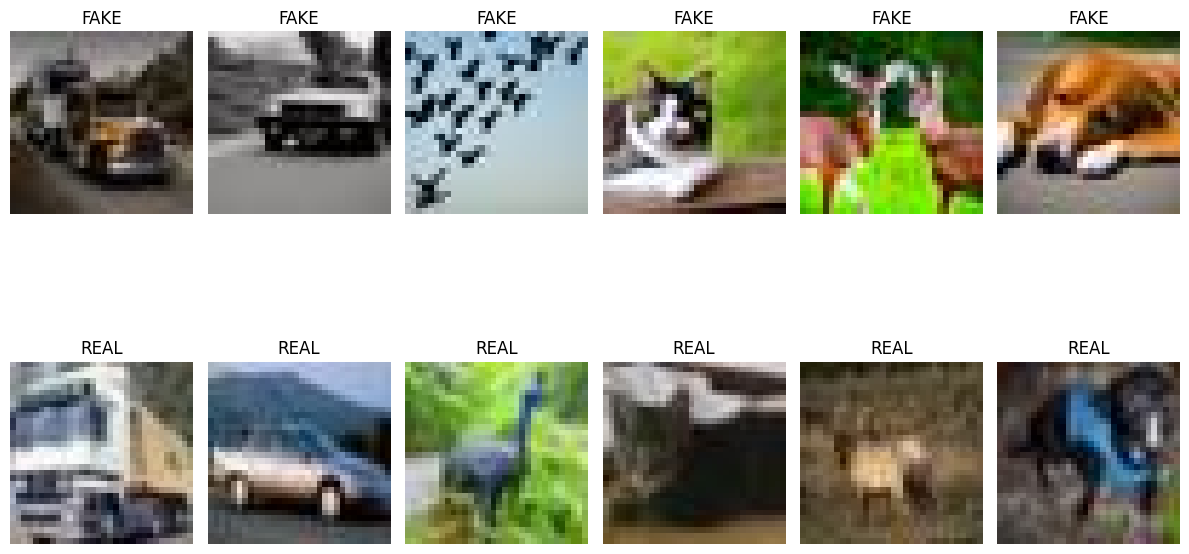

In [6]:
plt.figure(figsize=(12,8))

for i , class_name in enumerate(os.listdir(DATA_TRAIN_DIR)):
    class_path = os.path.join(DATA_TRAIN_DIR,class_name)
    images = os.listdir(class_path)[:6]

    for j,image_name in enumerate(images):
        image_path = os.path.join(class_path,image_name)
        image = Image.open(image_path)

        plt.subplot(2,6,i*6+j+1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

## Loading Dataset as Tensorflow Dataset

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_TRAIN_DIR,
    image_size = (IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = "training",
    seed = SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_TRAIN_DIR,
    image_size = (IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = "validation",
    seed = SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_TEST_DIR,
    image_size = (IMAGE_HEIGHT,IMAGE_WIDTH)
)


Found 100000 files belonging to 2 classes.
Using 80000 files for training.
Found 100000 files belonging to 2 classes.
Using 20000 files for validation.
Found 20000 files belonging to 2 classes.


## Building Baseline CNN Model

In [8]:
inputs = tf.keras.layers.Input(shape=(32,32,3))

x = tf.keras.layers.Conv2D(32,3,padding="same")(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D(2)(x)


x = tf.keras.layers.Conv2D(64,3,padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D(2)(x)


x = tf.keras.layers.Conv2D(128,3,padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D(2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model = tf.keras.models.Model(inputs,outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 32, 32, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496 

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy'],
    loss='binary_crossentropy'
)

In [10]:
early_stopping = EarlyStopping(
    patience=7,
    monitor='val_loss',
    restore_best_weights=True
)

lr_reducer = ReduceLROnPlateau(
    patience=5,
    monitor='val_loss',
    factor=0.2,
    min_lr=1e-6,
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[early_stopping,lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/30
2500/2500 [==============================] - 37s 10ms/step - loss: 0.2846 - accuracy: 0.8850 - val_loss: 0.2224 - val_accuracy: 0.9079 - lr: 0.0010
Epoch 2/30
2500/2500 [==============================] - 29s 12ms/step - loss: 0.2025 - accuracy: 0.9212 - val_loss: 0.2298 - val_accuracy: 0.9141 - lr: 0.0010
Epoch 3/30
2500/2500 [==============================] - 28s 11ms/step - loss: 0.1753 - accuracy: 0.9332 - val_loss: 0.1552 - val_accuracy: 0.9423 - lr: 0.0010
Epoch 4/30
2500/2500 [==============================] - 32s 13ms/step - loss: 0.1556 - accuracy: 0.9413 - val_loss: 0.2749 - val_accuracy: 0.9096 - lr: 0.0010
Epoch 5/30
2500/2500 [==============================] - 34s 13ms/step - loss: 0.1396 - accuracy: 0.9474 - val_loss: 0.1780 - val_accuracy: 0.9323 - lr: 0.0010
Epoch 6/30
2500/2500 [==============================] - 32s 13ms/step - loss: 0.1247 - accuracy: 0.9534 - val_loss: 0.1978 - val_accuracy: 0.9243 - lr: 0.0010
Epoch 7/30
2500/2500 [========================

## Saving model

In [12]:
model.save("../models/cnn/Baseline_model.keras")

## Traning and Validation Curve

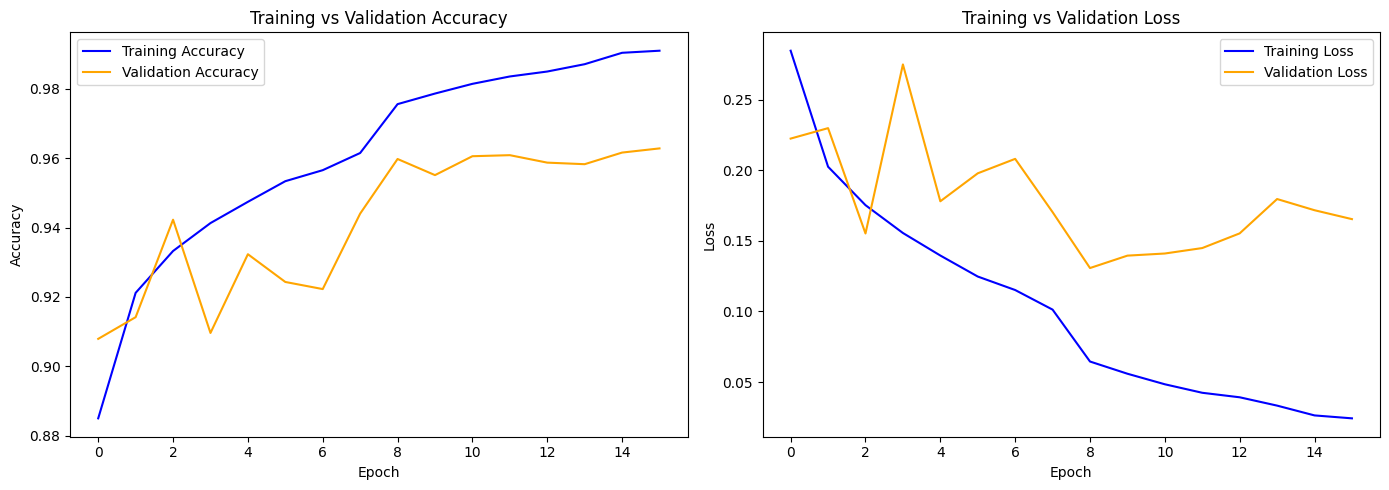

In [13]:
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy", color='blue')
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2) 
plt.plot(history.history["loss"], label="Training Loss", color='blue')
plt.plot(history.history["val_loss"], label="Validation Loss", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Final Test Evaluation

In [14]:
# Test Accuracy
test_results = model.evaluate(test_ds,return_dict=True)
print("Test Results")

for metric,value in test_results.items():
    print(f"{metric} : {value}")

625/625 [==============================] - 5s 7ms/step - loss: 0.1260 - accuracy: 0.9592
Test Results
loss : 0.12595495581626892
accuracy : 0.9592000246047974


In [15]:
# Classification Report
y_true = []
y_prob = []

for images , labels in test_ds:
    predictions = model.predict(images,verbose=0).ravel()

    y_prob.extend(predictions)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob>=0.5).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names =["FAKE","REAL"]
))

              precision    recall  f1-score   support

        FAKE       0.95      0.97      0.96     10000
        REAL       0.97      0.95      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



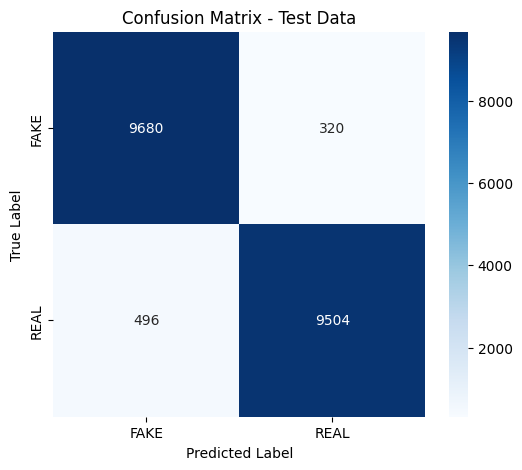

In [16]:
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["FAKE" , "REAL"],yticklabels=["FAKE","REAL"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Data")
plt.show()

In [17]:
# ROC Curve & ROC
fpr , tpr , threshold = roc_curve(y_true,y_prob)
auc_score = roc_auc_score(y_true,y_prob)

print(f"ROC-AUC : {auc_score:.4f}")

ROC-AUC : 0.9929


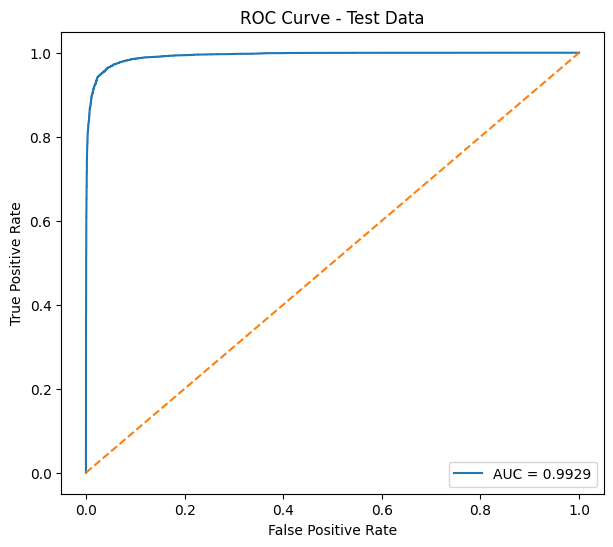

In [18]:
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.show()